In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/homeprices.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [4]:
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [5]:
df.shape

(5, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [7]:
df.describe()

,area,price
count,5.000000,5.000000
mean,3280.000000,626000.000000
std,540.370243,74949.983322
min,2600.000000,550000.000000
25%,3000.000000,565000.000000
50%,3200.000000,610000.000000
75%,3600.000000,680000.000000
max,4000.000000,725000.000000


In [9]:
#Misiing Values and duplicates

df.isnull().sum()


area     0
price    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

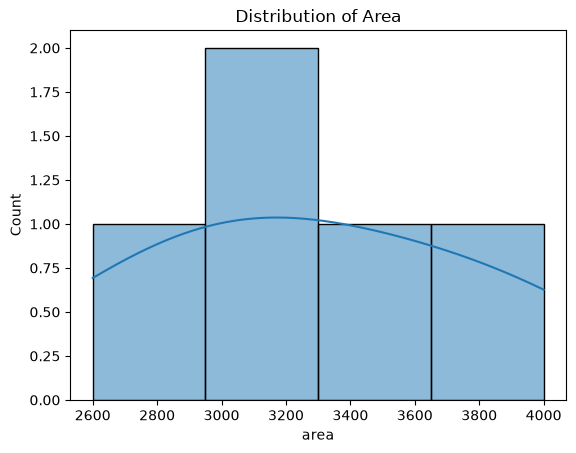

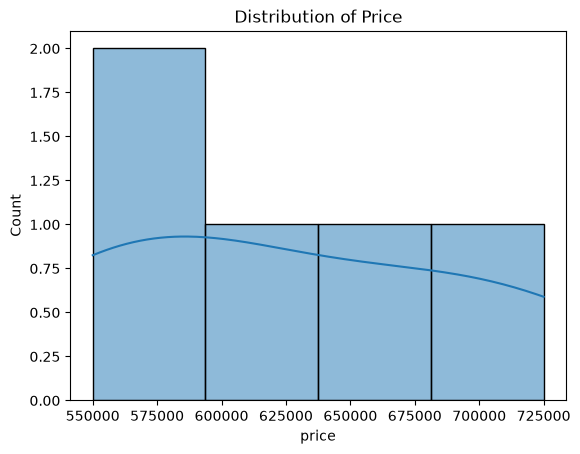

In [ ]:
#Univariant Analysis
sns.histplot(df['area'], kde=True)
plt.title('Distribution of Area')
plt.show()

sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.show()

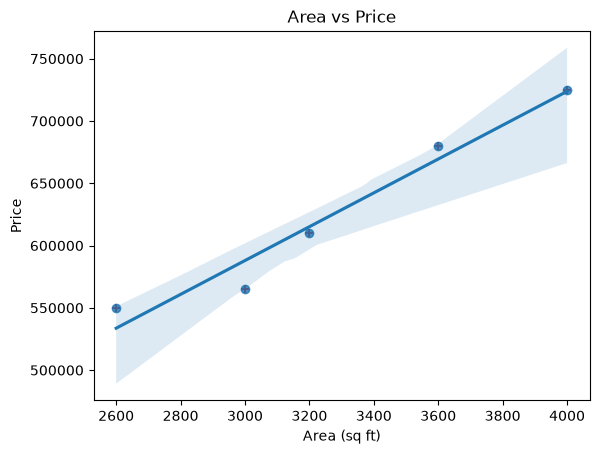

In [19]:
#Bi-Variant Analysis
plt.scatter(df['area'], df['price'], color='red', marker='+')
sns.regplot(x='area',y='price',data=df)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [20]:
df.corr()

,area,price
area,1.000000,0.978994
price,0.978994,1.000000


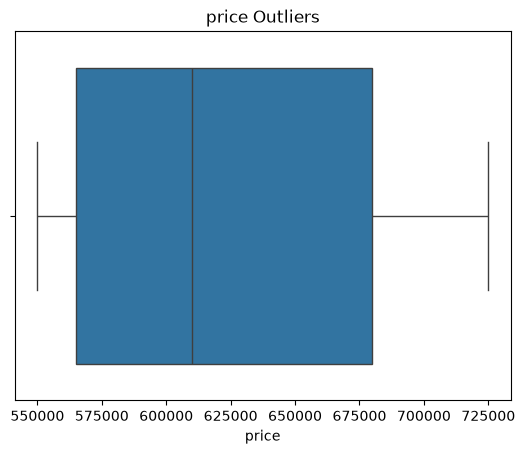

In [21]:
#Outlier Check

sns.boxplot(x=df['price'])
plt.title('price Outliers')
plt.show()

In [23]:
#Feature Engineering
X = df[['area']]
y = df['price']



In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(4, 1) (1, 1) (4,) (1,)


In [26]:
print("Train data:\n", X_train, y_train)

Train data:
    area
4  4000
2  3200
0  2600
3  3600 4    725000
2    610000
0    550000
3    680000
Name: price, dtype: int64


In [27]:
print("Test data:\n", X_test, y_test)

Test data:
    area
1  3000 1    565000
Name: price, dtype: int64


In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[128.27]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.115e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [29]:
print("Coefficient (slope):", model.coef_)
print("Intercept:", model.intercept_)

Coefficient (slope): [128.27102804]
Intercept: 211542.05607476638


In [31]:
y_pred = model.predict(X_test)
print("Prediction :", y_pred)
print("Actual :", y_test.values)

Prediction : [596355.14018692]
Actual : [565000]


In [34]:
predicted_price = model.predict(pd.DataFrame({'area': [3300]}))
print("Predicted price for 3300 sq ft:", predicted_price)

Predicted price for 3300 sq ft: [634836.44859813]


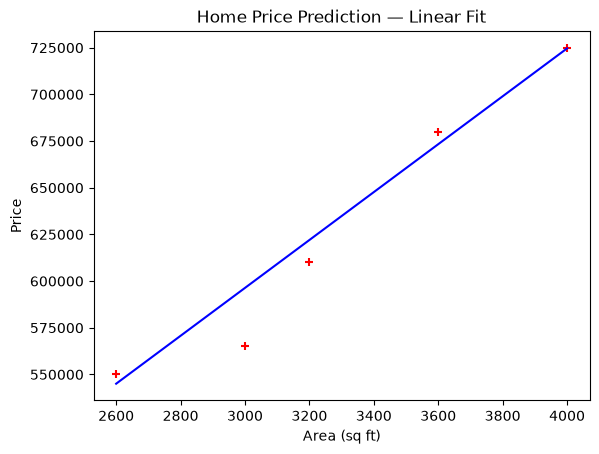

In [35]:
plt.scatter(df['area'], df['price'], color='red', marker='+')
plt.plot(df['area'], model.predict(df[['area']]), color='blue')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Home Price Prediction — Linear Fit')
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 31355.140186915873
MSE: 983144816.1411468
RMSE: 31355.140186915873
R² Score: nan


c:\Users\sivag\git-projects\ml-ai-genai-agentic-practice\slr-uk-house-price\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [38]:
import pickle

with open('../src/homeprice_model.pkl', 'wb') as file:
    pickle.dump(model,file)

In [40]:
with open('../src/homeprice_model.pkl','rb') as file:
    loaded_model = pickle.load(file)

print(loaded_model.predict(pd.DataFrame({'area' : [3300]})))

[634836.44859813]


2026-07-21 14:31:56.839 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-21 14:31:57.824 
  command:

    streamlit run c:\Users\sivag\git-projects\ml-ai-genai-agentic-practice\slr-uk-house-price\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-21 14:31:57.825 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-21 14:31:57.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-21 14:31:57.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-21 14:31:57.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-21 14:31:57.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in b